# 第21课 · 🎨 你的耳机每秒都在做矩阵乘法——DFT 矩阵与 Mel 矩阵，音频即线代

把《Art of Linear Algebra》的视角对准 Audio Core：
**DFT 是一次矩阵×向量（vector）；mel 特征是一次矩阵×向量。** 看懂这点，FFT 和 mel 滤波就从"黑箱公式"变成你已经会的线代。

**目标**：把 DFT 和 mel 变换分别写成矩阵形式，验证 `W @ x` 与 `fft` 数值吻合。

> **本课成功标准**：认出「耳机里的运算就是 matvec」——**不要求**手推完整 DFT 证明（那是 L37 的活）。

**为什么对 Aurora 重要**：矩阵视角下，FFT 是 DFT 矩阵的快速算法；mel 滤波是另一张矩阵左乘频谱。

**线代模块复盘（一张表）**：向量 → 点积/范数 → 矩阵乘法 → 特殊矩阵 → 特征/SVD → 方程组与可逆 → **音频里的 DFT/Mel 矩阵（本课）**。

← **上一课**　[L20 · 分解图谱](L20_visual_factorizations.ipynb)

> 上节课学习了 **分解图谱**：LU / QR / SVD 三种分解的几何意义对比。  
> 本课将探讨 **矩阵即滤波**。

## 本课剧情：矩阵就是你每天听到的声音

每次你播放一首歌，手机做了这些事：
1. 把音频切成一帧帧 → 每帧是一个长度 N 的向量 `x`
2. 做 FFT：`X = W · x`，W 是 N×N 的复数矩阵
3. 做 Mel 滤波：`m = M · X_power`，M 是（n_mels × N//2+1）的实数矩阵

两步都是**矩阵×向量**。没有任何"黑盒"——只是系数乘法和加法。

`W[k,n] = e^{-2πi·kn/N}` 是 DFT 矩阵的第 (k, n) 个元素。  
你可以不调用 `np.fft.fft`，自己 `np.exp` 出一行矩阵完成同样的工作。

Mel 矩阵 `M` 的每一行是一个三角形滤波器，`M @ p` 等于 `mel_filterbank()(p)`。  
两者在 Aurora 里分别封装为 `fft()` 和 `mel_filterbank()`，底层都是加权点积。

本课任务：
- 显式构造 8×8 DFT 矩阵 W，验证 `W @ x == np.fft.fft(x)`
- 理解 mel 矩阵形状：`M` 的每行是一个频带的加权系数
- 实现 `build_dft_matrix(N)` 并通过验证

## 开课前 2 分钟复习：W @ x 其实就是 DFT

- `x` 是长度 N 的信号向量
- `W` 是 N×N 的 DFT 矩阵
- `W @ x` 的每一行都是一次加权求和，正好对应一个频点

L37 会把这件事换成手写循环；现在先把矩阵视角记牢。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
from aurora.laviz import style, heatmap, mat_times_vec
from aurora.audio import fft, mel_filterbank, sine
style(); print('就绪')

就绪


## 符号入口：先看形状，再看运算

信号向量 `x` 的 shape 是 `(N,)`，DFT 矩阵 `W` 是 `(N, N)`，mel 矩阵 `M` 是 `(n_mels, N//2+1)`。矩阵乘法把输入的每个分量重新线性组合——输出的每个值是一次点积。

## 磨刀：DFT 公式 `exp(-2πi·kn/N)` 到底从哪来？

正式构造矩阵前，先花几分钟拆开这个公式——它不是符号的随意堆砌，每个部分都有具体含义。

**先讲个故事**：想象一个圆形跑道，均匀站着 N 个人，编号 n = 0, 1, …, N−1。"频率 k"就像一个跑得比别人快 k 倍的人——当 1 号频率的人走完整整一圈（2π 弧度）时，k 号频率的人已经走完了 k 圈。

- `n/N` 是"1 号频率的人走到第 n 位时，走了整圈的几分之几"（一个"圈数"）。
- 乘以 k 倍速度，"k 号频率的人在同一位置走了几圈"就是 `k·n/N`。
- 再乘以 2π，把"圈数"换算成"弧度角度"——正如把"小时"换算成"分钟"要乘 60，把"圈数"换算成"弧度"要乘 2π（一整圈 = 2π 弧度，这是弧度制的定义）。

所以 `2π·kn/N` 就是"频率 k、位置 n"对应的旋转角度——这正是 L06 学过的 `twiddle(k,n,N) = e^{-2πikn/N}`（旋转因子）在这里再次出场。

**那前面的负号呢？** DFT 要做的事情是"从信号里读出某个频率成分有多少"，数学上这一步是把信号向量 `x` 和"基准波形" `e^{+i2πkn/N}` 做**内积**——复数内积的定义里，要对第二个向量取**共轭**（`⟨a,b⟩ = Σ a[n]·conj(b[n])`）。而 `e^{+iθ}` 的共轭正好是 `e^{-iθ}`（虚部反号，L05 学过的"共轭 = 纵轴翻折"）。于是"读出频率成分"这一步的共轭操作，自动把指数变成了负号——这不是随意规定，而是"内积"这个动作本身要求的。反过来，"用各频率成分合成回原信号"（IDFT）就是正号，对应 W 的逆矩阵是共轭转置 `Wᴴ/N`（稍后会验证）。

下面用 N=4、k=1 这一行具体算一遍，把上面的故事变成看得见的数字。

In [3]:
import numpy as np

# 手算验证：N=4, k=1 这一行 —— 4个人均分一整圈，1号频率的人走一整圈
N4 = 4
k1 = 1
n4 = np.arange(N4)
angles = 2 * np.pi * k1 * n4 / N4        # 每个位置对应的旋转角度（弧度）
print('角度(弧度) =', np.round(angles, 4), ' 即', np.round(angles / np.pi, 2), '× π')
row1 = np.exp(-1j * angles)
print('W 第1行 (k=1) =', np.round(row1, 4))
print('手算应为 [1, -j, -1, j] ?', np.allclose(row1, [1, -1j, -1, 1j]))

角度(弧度) = [0.     1.5708 3.1416 4.7124]  即 [0.  0.5 1.  1.5] × π
W 第1行 (k=1) = [ 1.+0.j  0.-1.j -1.-0.j -0.+1.j]
手算应为 [1, -j, -1, j] ? True


### 补充：`np.outer(n, n)` 为什么就能一次性生成所有的 `k·n`？

`np.outer(a, b)` 叫**外积**（outer product）：给两个长度为 N 的向量 a、b，返回一个 N×N 矩阵，第 (i, j) 个元素就是 `a[i] * b[j]`——像小学做的乘法表：竖着排 a，横着排 b，格子里填两者的乘积。

```python
np.outer([1,2,3], [1,2,3])
# array([[1, 2, 3],
#        [2, 4, 6],
#        [3, 6, 9]])
```
第 2 行第 3 列（从 0 计数，即 i=1, j=2）的值是 `2×3=6`，正好是"第 i 个数 × 第 j 个数"。

回到 DFT：矩阵第 (k,n) 位置要放 `exp(-2πi·k·n/N)`，其中 `k·n` 这部分就是"频率编号 k"和"位置编号 n"的乘法表——用 `np.outer(k_idx, n_idx)` 一次性算出所有 k·n，再整体乘上 `-2πi/N`，最后对每个格子取 `np.exp`（NumPy 会自动逐元素运算），就拼出了完整的 W 矩阵，不需要写双重 for 循环。

In [4]:
demo_outer = np.outer([1, 2, 3], [1, 2, 3])
print(demo_outer)
print('第(1,2)位置 =', demo_outer[1, 2], ' 应等于 2*3 =', 2 * 3)

[[1 2 3]
 [2 4 6]
 [3 6 9]]
第(1,2)位置 = 6  应等于 2*3 = 6


## DFT 矩阵的构造

运行下面这格，观察 DFT 矩阵 `W` 的构造：`W[k,n] = exp(-2πi·kn/N)`。
构造完成后验证**正交性**：`W @ W^H / N = I`，最大误差应远小于机器精度。
这一步的意义：FFT 本质上是在对信号向量做矩阵乘法，只是通过蝶形递归把 O(N²) 优化为 O(N log N)。

In [5]:
import numpy as np

# DFT 矩阵 W_N：W[k,n] = exp(-2πi k n / N)
N = 8
n = np.arange(N)
W = np.exp(-2j * np.pi * np.outer(n, n) / N)  # shape (N,N)
print(f'DFT 矩阵 W_{N} shape = {W.shape}')
print(f'W 的行：正交性验证  W @ W^H / N = I')
ortho_err = np.max(np.abs(W @ W.conj().T / N - np.eye(N)))
print(f'最大误差 = {ortho_err:.2e}  （应接近 0）')
# 对比 numpy.fft.fft
x = np.array([1.,2.,3.,4.,5.,6.,7.,8.])
print(f'W@x ≈ np.fft.fft(x) ? {np.allclose(W @ x, np.fft.fft(x))}')


DFT 矩阵 W_8 shape = (8, 8)
W 的行：正交性验证  W @ W^H / N = I
最大误差 = 7.31e-16  （应接近 0）
W@x ≈ np.fft.fft(x) ? True


## 前向锚点 · L37 将用循环写同一变换（2 分钟）

本课用矩阵形式：`X = W @ x`，与 `np.fft.fft(x)` 数值相同（`atol=1e-10`）。

**L37** 会换一种写法：不用整矩阵，用双重循环直接写
`X[k] = Σₙ x[n]·e^{-2πikn/N}`——两种写法等价；
矩阵版帮你记住「FFT = 线性变换」，循环版帮你记住每个指数项。


### 补充：FFT 到底怎么把 O(N²) 变成 O(N log N)？

矩阵乘法 `W @ x` 要算出 N 个输出，每个输出都是一次长度 N 的点积（N 次乘法），一共 `N × N = N²` 次乘法——这是矩阵版慢的原因。

FFT 的核心技巧叫**分治**（divide and conquer）：

1. 把长度 N 的信号按下标奇偶拆成两半——偶数下标 `x[0], x[2], x[4], …` 和奇数下标 `x[1], x[3], x[5], …`，每半长度 N/2。
2. DFT 公式本身的代数性质保证：**长度 N 的 DFT 结果，可以只用两个长度 N/2 的 DFT 结果拼出来**（配合一些"旋转因子"做微调），不需要重新做一次 N/2×N/2 的矩阵乘法。
3. 于是"算 1 个长度 N 的 DFT"，变成了"算 2 个长度 N/2 的 DFT，再花 O(N) 时间拼起来"。
4. 这个拆分可以一直递归下去：N/2 拆成 2 个 N/4，N/4 拆成 2 个 N/8……直到长度为 1（不用算，直接返回自己）。

拆分的层数是 `log₂N`（每层长度减半，减几次能到 1，就是几层）；每一层要把所有子结果拼起来，加起来总共只需要 O(N) 次运算。所以总时间 = 每层 O(N) × 共 log₂N 层 = **O(N log N)**。这就是"蝶形"（butterfly）名字的来历——两个子结果按"旋转因子"配对合并的那一步，画在图上像一对蝴蝶翅膀。L37 会用循环把这整个过程写出来。

In [6]:
for Ndemo in [8, 64, 512, 4096]:
    naive_ops = Ndemo ** 2
    fft_ops = int(Ndemo * np.log2(Ndemo))
    print(f'N={Ndemo:5d}  矩阵版≈{naive_ops:>9d}次乘法   FFT版≈{fft_ops:>7d}次   加速比≈{naive_ops/fft_ops:.1f}x')

N=    8  矩阵版≈       64次乘法   FFT版≈     24次   加速比≈2.7x
N=   64  矩阵版≈     4096次乘法   FFT版≈    384次   加速比≈10.7x
N=  512  矩阵版≈   262144次乘法   FFT版≈   4608次   加速比≈56.9x
N= 4096  矩阵版≈ 16777216次乘法   FFT版≈  49152次   加速比≈341.3x


## 简化 mel 滤波器：手动构造三角形矩阵

运行下面这格，看手动构造的 3-filter mel 矩阵（8 个 FFT bin 上）：
每行是一个三角形滤波器，峰值在中心频率处，两侧线性衰减到 0。
`M @ mag` 把功率谱（power spectrum）向量压缩成 3 维 mel 能量向量——这正是 mel 特征提取的核心操作。

### 补充：为什么要用 `N_mels+2` 个端点，而不是 `N_mels` 个？

每个三角形滤波器要靠三个"锚点"确定形状：**左脚（值为 0）→ 峰顶（值为 1）→ 右脚（值为 0）**——单独一个滤波器需要 3 个点。

但相邻滤波器是"肩并肩"排列、彼此共享端点的：第 1 个滤波器的"右脚"就是第 2 个滤波器的"左脚"……这里的构造还要求每个滤波器同时确定"上升斜率"和"下降斜率"，用的是三个相邻端点的窗口：第 `m` 个滤波器用 `centers[m]`（左脚）、`centers[m+1]`（峰顶）、`centers[m+2]`（右脚）。

想让最后一个滤波器（第 `N_mels-1` 个）也能取到 `centers[N_mels+1]`，端点数组的长度就必须是 `N_mels + 2`——这不是随便选的数字，是"每个滤波器占 3 个连续端点、相邻滤波器共享端点"这个几何关系直接推出来的。（也可以用别的补边方式，比如两端各加一个虚拟镜像点，效果等价，只是这里选择了最直接、不需要额外假设的写法。）

下面用 `N_mels=3` 具体数一遍：应该有 5 个端点。

In [7]:
N_mels_demo = 3
centers_demo = np.linspace(0, 4, N_mels_demo + 2)
print('centers =', centers_demo, ' 长度 =', len(centers_demo), '(= N_mels+2 =', N_mels_demo + 2, ')')
for m in range(N_mels_demo):
    lo, cen, hi = centers_demo[m], centers_demo[m + 1], centers_demo[m + 2]
    print(f'滤波器 {m}: 左脚={lo}, 峰顶={cen}, 右脚={hi}')

centers = [0. 1. 2. 3. 4.]  长度 = 5 (= N_mels+2 = 5 )
滤波器 0: 左脚=0.0, 峰顶=1.0, 右脚=2.0
滤波器 1: 左脚=1.0, 峰顶=2.0, 右脚=3.0
滤波器 2: 左脚=2.0, 峰顶=3.0, 右脚=4.0


In [8]:
import numpy as np

# Mel 滤波器组 = 矩阵乘法 M @ |X|²
# 简化演示：手动构造 3 个三角形滤波器（8 个 FFT bin 上）
N_fft, N_mels = 8, 3
bins = np.arange(N_fft // 2 + 1, dtype=float)  # [0, 1, 2, 3, 4]
# 修复：使用 N_mels+2 个端点（含边界 0 和 N_fft//2）
# 每个滤波器 m 用相邻三元组 (centers[m], centers[m+1], centers[m+2]) 作为 lo/cen/hi
centers = np.linspace(0, N_fft//2, N_mels+2)  # [0.0, 1.0, 2.0, 3.0, 4.0]
M = np.zeros((N_mels, len(bins)))
for m in range(N_mels):
    lo, cen, hi = centers[m], centers[m+1], centers[m+2]
    M[m] = np.clip(np.where(bins<=cen, (bins-lo)/(cen-lo+1e-9),
                             (hi-bins)/(hi-cen+1e-9)), 0, 1)
print(f'Mel 矩阵 M shape = {M.shape}  (N_mels × N_fft//2+1)')
print(np.round(M, 2))
mag = np.array([0.1, 0.5, 1.0, 0.8, 0.3])  # 模拟功率谱 |X|²
mel_energy = M @ mag
print(f'Mel 能量 = {np.round(mel_energy, 4)}')
assert M[0].sum() > 0, '边界修复失败：filter 0 不应为全零'
print('✅ mel 矩阵边界验证通过（filter 0 非全零）')


Mel 矩阵 M shape = (3, 5)  (N_mels × N_fft//2+1)
[[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]]
Mel 能量 = [0.5 1.  0.8]
✅ mel 矩阵边界验证通过（filter 0 非全零）


### 补充：`+1e-9` 是干什么的？为什么滤波器太多会出现全零行？

上面代码里 `(cen-lo+1e-9)` 和 `(hi-cen+1e-9)` 的 `1e-9` 是一个**极小值保护**（常叫 epsilon）：专门防止分母恰好是 0 时程序崩溃（除以 0 在浮点数里会得到 `inf` 或 `nan`）。正常情况下 `cen` 和 `lo` 是两个不同的点，分母不会真的是 0，这时加上 `1e-9` 对结果的影响也在 1e-9 这个量级——小到完全可以忽略，**不会"污染"正常结果**，只在极端情况下防止报错。

那"很多滤波器全零"是怎么发生的？——当**滤波器数量（n_mels）远多于可用的频率 bin 数量**时。比如 `n_fft=64` 只有 33 个频率 bin（`n_fft//2+1`），如果硬塞 128 个滤波器，很多滤波器的"左脚-峰顶-右脚"之间的间距会小于 1 个 bin 的宽度——这样一来，没有任何一个整数 bin 能同时落在"上升沿≥0"和"下降沿≥0"的交集里，`min(上升, 下降)` 在每个 bin 上算出来都是负数，被 `clip(...,0,None)` 直接裁成 0，整行就塌缩成全零。

这不是 bug，而是"分辨率不够"的必然结果：**频率 bin 数量决定了最多能有意义地切出多少个不重叠的滤波器**。经验法则是让 `n_mels` 明显小于 `n_fft//2+1`（差 5~10 倍以上比较安全）。下面用 Aurora 真正的 `mel_filterbank()` 复现这个退化现象：

In [9]:
M_degenerate = mel_filterbank(n_mels=128, n_fft=64, sample_rate=16000)
zero_rows = np.sum(np.all(M_degenerate == 0, axis=1))
print(f'n_mels=128, n_fft=64 → 频率 bin 数 = {M_degenerate.shape[1]}')
print(f'全零滤波器行数 = {zero_rows} / {M_degenerate.shape[0]}')
print('原因：bin 数量(33)远小于滤波器数量(128)，大量滤波器挤在同一个bin上，权重塌缩为全零。')

n_mels=128, n_fft=64 → 频率 bin 数 = 33
全零滤波器行数 = 68 / 128
原因：bin 数量(33)远小于滤波器数量(128)，大量滤波器挤在同一个bin上，权重塌缩为全零。


## 1. DFT 是一个矩阵 W

为什么 FFT 是矩阵乘法？

普通傅里叶变换的定义：`X[k] = Σₙ x[n] · e^{-2πi·kn/N}`  
每个输出 `X[k]` 是输入 `x[n]` 的**加权求和**——这就是一次点积。

把 N 个点积堆叠成矩阵，得到 **DFT 矩阵** W：

$$W[k,n] = e^{-2\pi i \cdot kn/N}, \quad k,n = 0,1,\ldots,N-1$$

手算例子（N=4, k=1, n=2）：`W[1,2] = exp(-2πi·2/4) = exp(-πi) = -1`

性质：
- **酉矩阵**（unitary）：`W·Wᴴ = N·I`，即 `(1/√N)·W` 是正交矩阵
- **对称**：`W[k,n] = W[n,k]`（DFT 矩阵转置等于本身）
- **逆变换**：IDFT 矩阵 = `Wᴴ/N`（共轭转置除以 N）

所以 `W @ x` 与 `np.fft.fft(x)` 完全等价——只是把隐含的矩阵显式写出来。

### 磨刀：还记得 L06 的欧拉公式吗？—— 单位圆速查表

L06 学过：`e^{iθ} = cosθ + i·sinθ`，即"角度 θ 对应单位圆上的点 (cosθ, sinθ)"。这里给一张常用角度的速查表，白板挑战会直接用到：

| θ (弧度) | θ (角度) | cos θ | sin θ | e^{iθ} |
|---|---|---|---|---|
| 0 | 0° | 1 | 0 | 1 |
| π/6 | 30° | √3/2 | 1/2 | √3/2 + i/2 |
| π/4 | 45° | √2/2 | √2/2 | √2/2 + i√2/2 |
| π/3 | 60° | 1/2 | √3/2 | 1/2 + i√3/2 |
| π/2 | 90° | 0 | 1 | i |
| π | 180° | −1 | 0 | −1 |
| 3π/2 | 270° | 0 | −1 | −i |
| 2π | 360° | 1 | 0 | 1 |

**逐步算一遍白板题**：`W[2,3] = exp(-2πi·2·3/8) = exp(-2πi·6/8) = exp(-3πi/2)`

- 第一步：化简角度。`-2π·6/8 = -12π/8 = -3π/2`（弧度）。
- 第二步：`-3π/2` 换算成角度制，`-3π/2 = -270°`，等价于 `+90°`（转一整圈 360° 位置不变：`-270°+360°=90°`）。
- 第三步：查表，`90°` 对应 `cos=0, sin=1`。
- 第四步：`e^{-i3π/2} = e^{i(-3π/2 + 2π)} = e^{iπ/2} = cos(π/2)+i·sin(π/2) = 0 + i·1 = i`（也就是 `j`）。

下面代码把这四步全部验证一遍。

In [10]:
# 逐步验证 exp(-3πi/2) = j
theta = -3 * np.pi / 2
theta_equiv = theta + 2 * np.pi            # 转一整圈，等价角度
print(f'原始角度 = {theta:.4f} rad = {np.degrees(theta):.1f}°')
print(f'加 2π 后的等价角度 = {theta_equiv:.4f} rad = {np.degrees(theta_equiv):.1f}°')
print(f'cos = {np.cos(theta):.4f}, sin = {np.sin(theta):.4f}')
result = np.cos(theta) + 1j * np.sin(theta)
print(f'e^(-i3π/2) = {result:.4f}  (应为 0+1j，即 j)')
assert np.isclose(result.real, 0) and np.isclose(result.imag, 1)
print('✅ 与白板 Q1 的答案一致')

原始角度 = -4.7124 rad = -270.0°
加 2π 后的等价角度 = 1.5708 rad = 90.0°
cos = -0.0000, sin = 1.0000
e^(-i3π/2) = -0.0000+1.0000j  (应为 0+1j，即 j)
✅ 与白板 Q1 的答案一致


### 补充：Wᴴ（共轭转置）到底是什么？为什么"正交性验证"要用它，还要除以 N？

**先从一个复数说起**：一个复数 `z = a+bi` 的"长度"（模）平方是 `|z|² = a²+b²`。怎么用代数算出来？——用 z 乘以它的**共轭** `z̄ = a-bi`：`z·z̄ = (a+bi)(a-bi) = a²+b² = |z|²`。如果只是 `z·z`（不取共轭），得到的是 `a²-b²+2abi`，一般是个复数，不是"长度"。**共轭**（把虚部反号）正是让复数乘法算出"实数长度"的关键动作。

这个技巧原样搬到向量上：对于一个含复数的向量 `v`，它的"长度平方"是 `v^H v`（先把每个分量取共轭，再转置成行向量，点乘自己），而不是普通的 `v^T v`。这里的 `v^H`（读作"v 的共轭转置"，Hermitian transpose）= 先共轭、再转置；代码里就是 `v.conj().T`。

**回到 DFT 矩阵**：`W @ W.conj().T` 这一步，本质是在算"W 的每一行，和自己（及其他行）的复数内积"。如果所有行两两正交、每行"长度"都是 `√N`（每行是 N 个模长为 1 的旋转因子求和的结果），那么 `W @ Wᴴ` 算出来就应该是 `N·I`——对角线是每行自己的长度平方 N，非对角线（不同行的内积）应该是 0。**除以 N** 就是把"长度是 √N"这件事换算掉，让结果变成标准的单位矩阵 `I`，方便和"正交"这个概念对齐。

**"酉矩阵"（unitary）和"正交矩阵"（orthogonal）是同一个概念在实数/复数世界的两个名字**：
- 实数矩阵 Q 满足 `Qᵀ Q = I`，叫**正交矩阵**（转置就够了，因为实数的共轭就是它自己）。
- 复数矩阵 U 满足 `Uᴴ U = I`，叫**酉矩阵**（必须用共轭转置，原因见上面"复数长度"那段）。

`(1/√N)·W` 就是一个酉矩阵——这不是凑巧的性质，而是决定了两件很实际的事：
1. **求逆几乎不花钱**：一般矩阵求逆很贵（要解方程组），但酉矩阵的逆就是它的共轭转置 `Wᴴ/N`——这就是为什么 IDFT（逆变换）可以直接用 `Wᴴ/N`，不用另外算逆矩阵。
2. **能量不丢不增（Parseval 定理）**：信号在时域的"能量"（`Σ|x[n]|²`）和在频域的"能量"（`Σ|X[k]|²/N`）相等——保证做 FFT/IFFT 不会凭空丢失或制造能量，这也是后面做频谱分析、设计滤波器时敢放心来回变换的根本原因。

下面顺便验证一下：如果只用**普通转置**（不取共轭），`W @ W.T / N` 并不会等于单位矩阵——共轭这一步是必需的，不能省。

In [11]:
N8 = 8
k_idx = np.arange(N8)[:, None]
n_idx = np.arange(N8)[None, :]
W8 = np.exp(-2j * np.pi * k_idx * n_idx / N8)

conj_result = W8 @ W8.conj().T / N8
plain_result = W8 @ W8.T / N8

print('共轭转置版 W@Wᴴ/N ≈ I ?', np.allclose(conj_result, np.eye(N8)))
print('普通转置版 W@Wᵀ/N ≈ I ?', np.allclose(plain_result, np.eye(N8)))
print('\n普通转置版的对角线（大多不是 1，明显不是单位矩阵，证明必须用共轭）:')
print(np.round(np.diag(plain_result).real, 3))

共轭转置版 W@Wᴴ/N ≈ I ? True
普通转置版 W@Wᵀ/N ≈ I ? False

普通转置版的对角线（大多不是 1，明显不是单位矩阵，证明必须用共轭）:
[ 1.  0.  0. -0.  1. -0.  0.  0.]


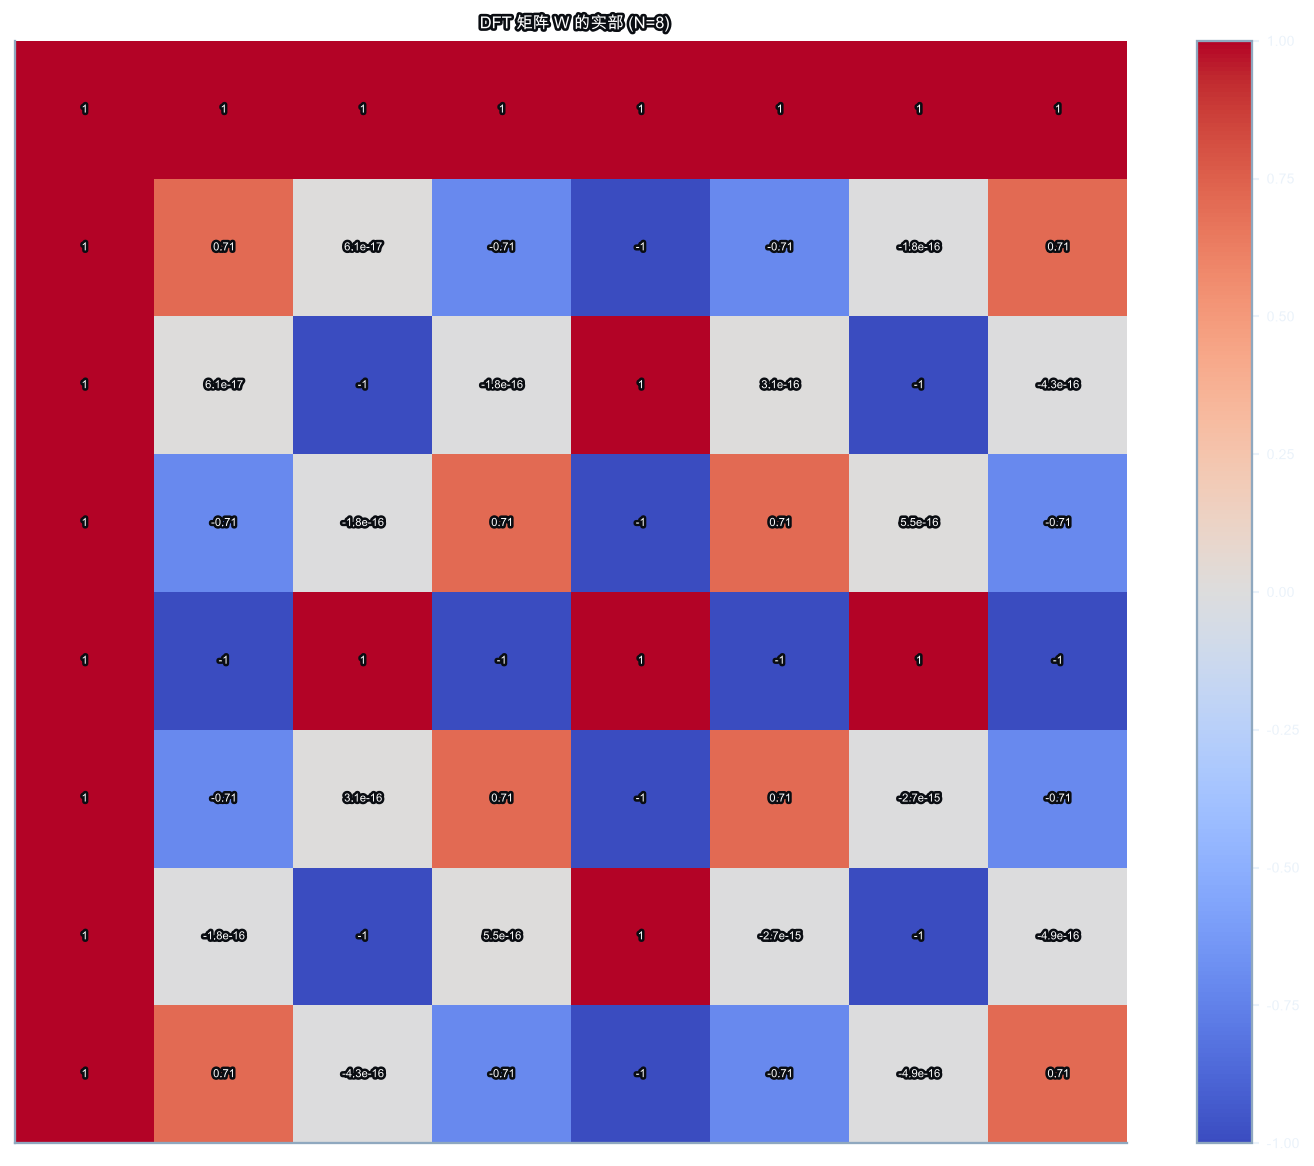

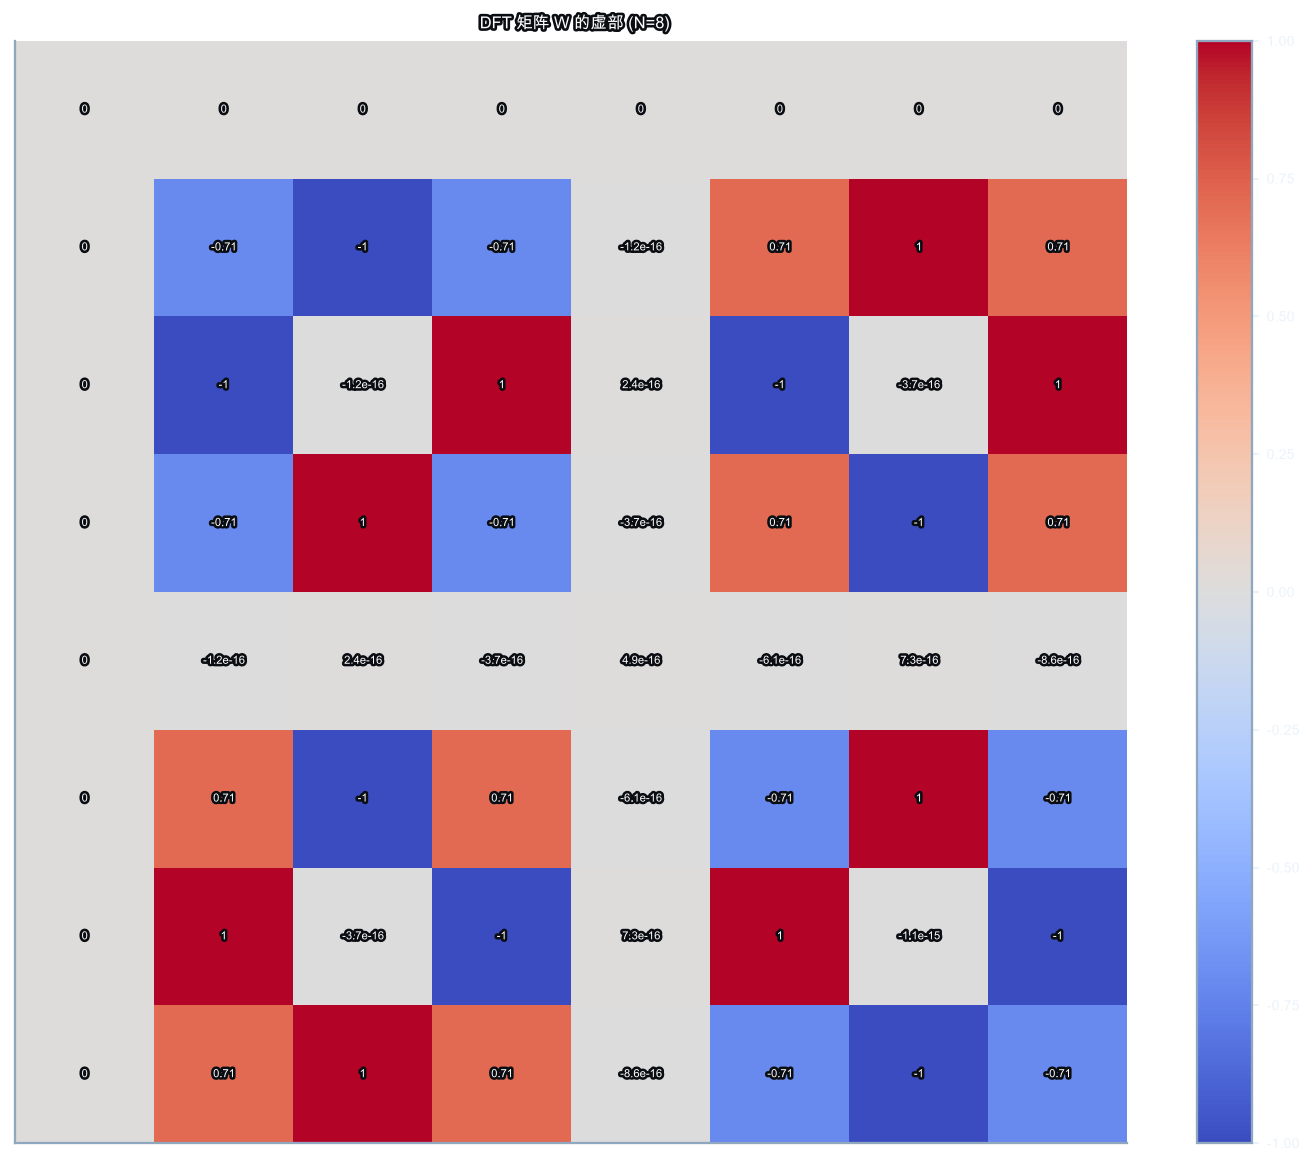

In [12]:
N = 8
k = np.arange(N)[:, None]; n = np.arange(N)[None, :]
W = np.exp(-2j*np.pi*k*n/N)        # DFT 矩阵
heatmap(W.real, title='DFT 矩阵 W 的实部 (N=8)', cmap='coolwarm');
heatmap(W.imag, title='DFT 矩阵 W 的虚部 (N=8)', cmap='coolwarm');

## 2. 验证：`W·x` 和我们手写的 FFT 完全一致

`W @ x` 与 `src/aurora/audio/transforms.py` 中的 `fft()` 算的是同一变换：前者是 O(N²) 的显式矩阵乘，后者是 O(N log N) 的蝶形递归，两者数值结果相差不超过浮点误差（`atol=1e-10`）。`mel_filterbank()` 在 `src/aurora/audio/mel.py` 中同理——它直接返回滤波器矩阵 `M`，所谓「mel 特征提取」就是一次 `M @ p`（`p` 是功率谱，power spectrum），没有别的隐藏步骤。

In [13]:
x = sine(1.0, duration=N/8, sample_rate=8)[:N]   # 任取一段长度为 N 的信号
X_matrix = W @ x          # 矩阵 × 向量
X_fft = fft(x)            # 我们手写的 FFT
print('W·x 与 fft(x) 一致:', np.allclose(X_matrix, X_fft))
assert np.allclose(X_matrix, X_fft, atol=1e-10)
print('✅ FFT 的本质 = 一次矩阵×向量(只是算得更快)。')

W·x 与 fft(x) 一致: True
✅ FFT 的本质 = 一次矩阵×向量(只是算得更快)。


## 3. mel 滤波器组（mel filterbank）也是一个矩阵

mel 特征 = `M · p`，其中 `M` 是 (n_mels × n_freq) 的滤波器矩阵，`p` 是功率谱向量。画出 M——一排漂亮的三角滤波器。

### 补充：滤波器为什么长成"三角形"，而不是矩形或高斯？

先说人耳的特点：人耳对频率的感知不是"线性"的，而更接近"对数"——你能轻松分辨 100Hz 和 200Hz 的差别（虽然只差 100Hz），却很难分辨 5000Hz 和 5100Hz 的差别（同样差 100Hz）。心理声学的测量结果大致是"低频分得细、高频分得粗"，mel 刻度就是把频率轴按这个规律重新拉伸/压缩（低频段展开、高频段压缩）后的新刻度。

那为什么滤波器形状选三角形，而不是矩形（方块）或高斯（钟形曲线）？
- **矩形**：一刀切，某个 bin 要么 100% 算进这个频带，要么 0%，边界处的微小频率抖动会让能量"跳变"到相邻频带，不够平滑。
- **高斯**：形状平滑，但要算指数函数，理论上无限延伸（没有干脆的边界），计算量更大，还要额外决定"多宽算够宽"。
- **三角形**：折中方案——两段直线（线性插值）就能保证中心频率权重最大、向两侧平滑衰减到 0，只需要加减乘除，天然有清晰的边界（超出范围严格为 0）。这就是几乎所有语音识别系统都用三角形 mel 滤波器组的原因：**便宜、够用、效果和高斯相差无几**。

一句话总结：选三角形不是因为它"最像"人耳的响应曲线，而是"用最简单的形状，换取足够好的听觉近似"的工程折中。下面直接对比矩形滤波器和三角形滤波器在同一组频率 bin 上的权重差异：

In [14]:
bins_demo = np.arange(20, dtype=float)
rect = np.where((bins_demo >= 5) & (bins_demo < 10), 1.0, 0.0)             # 矩形：硬切
tri = np.clip(np.where(bins_demo <= 7.5, (bins_demo - 5) / 2.5, (10 - bins_demo) / 2.5), 0, 1)  # 三角形：线性过渡
print('矩形滤波器权重  :', np.round(rect, 2))
print('三角形滤波器权重:', np.round(tri, 2))
print('矩形在 bin=4→5 处从 0 直接跳到 1；三角形是 0→0.2→0.4…平滑爬升。')

矩形滤波器权重  : [0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
三角形滤波器权重: [0.  0.  0.  0.  0.  0.  0.4 0.8 0.8 0.4 0.  0.  0.  0.  0.  0.  0.  0.
 0.  0. ]
矩形在 bin=4→5 处从 0 直接跳到 1；三角形是 0→0.2→0.4…平滑爬升。


mel 滤波器矩阵形状: (10, 33) = (n_mels, n_freq_bins)


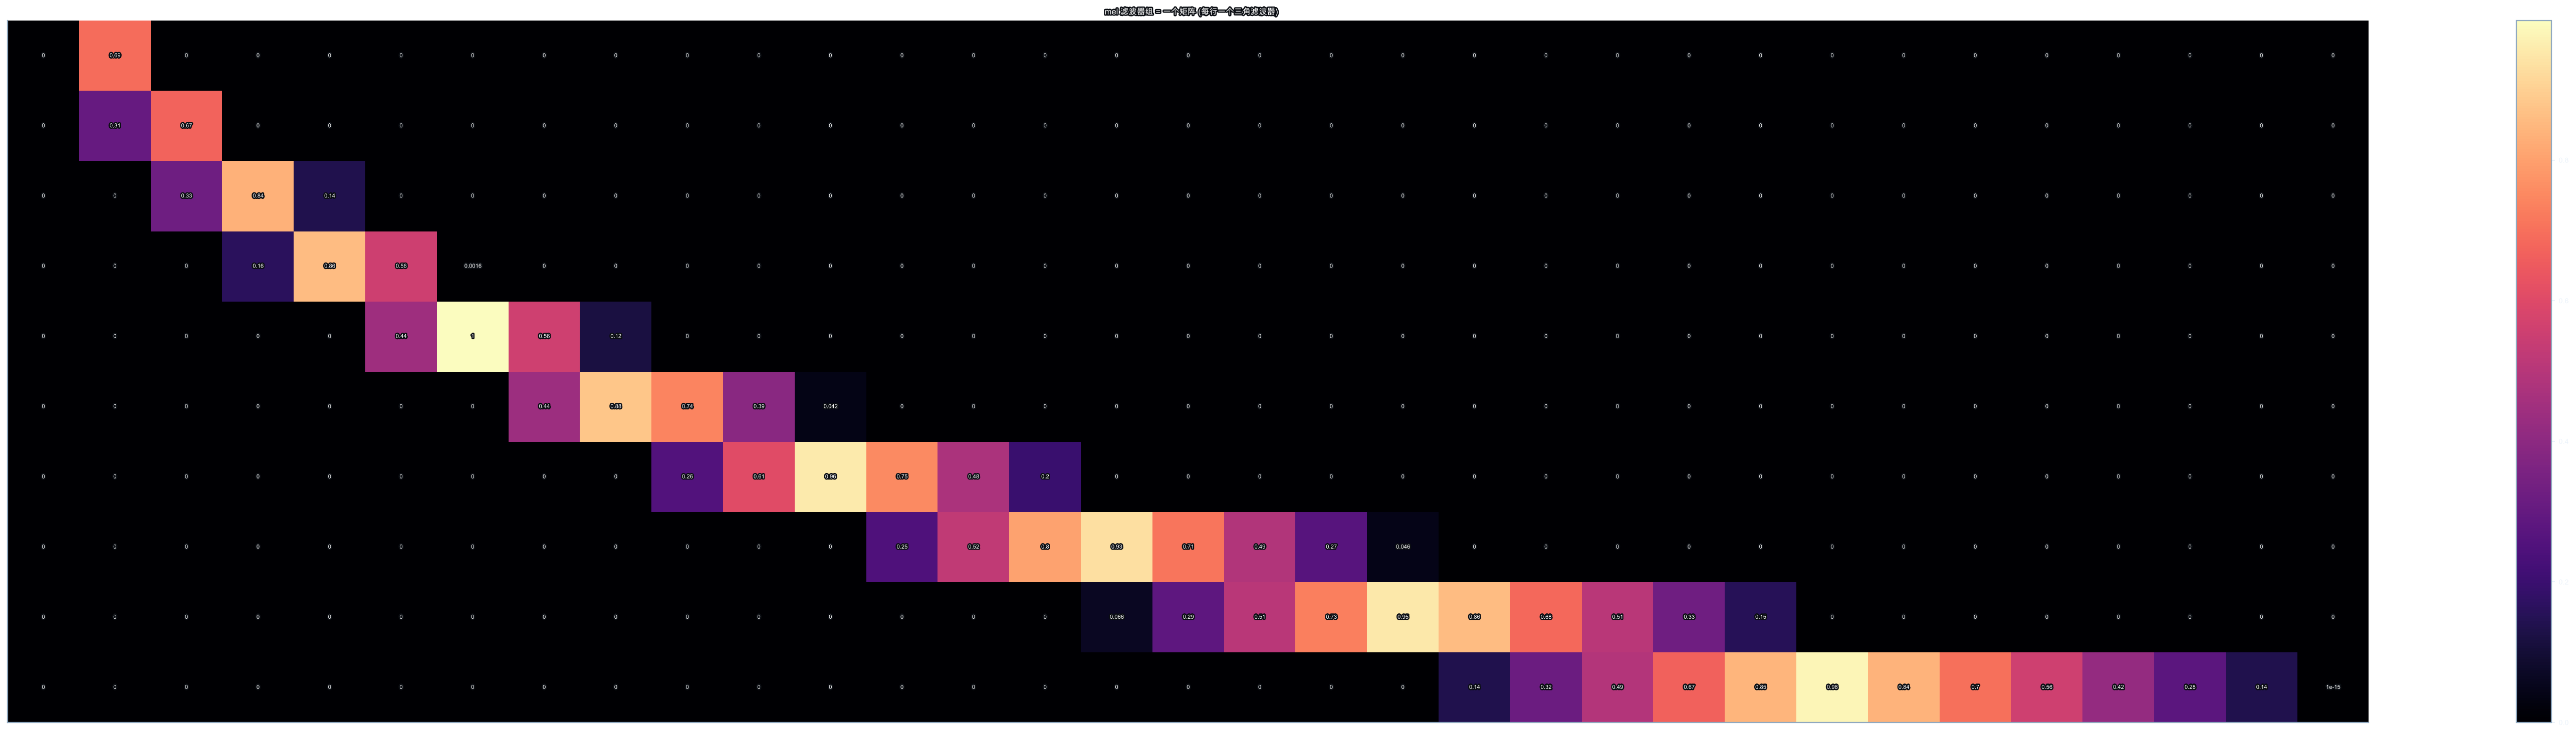

In [15]:
M = mel_filterbank(n_mels=10, n_fft=64, sample_rate=16000)
print('mel 滤波器矩阵形状:', M.shape, '= (n_mels, n_freq_bins)')
heatmap(M, title='mel 滤波器组 = 一个矩阵 (每行一个三角滤波器)', cmap='magma');

In [16]:
# 验证：mel_filterbank() 返回的就是矩阵 M——mel 特征 = M @ p，仅此而已
p_full = np.abs(fft(sine(440., duration=64/16000, sample_rate=16000))[:M.shape[1]])**2
M_ref = mel_filterbank(n_mels=10, n_fft=64, sample_rate=16000)
assert p_full.shape == (M_ref.shape[1],), f'shape 不匹配: {p_full.shape}'
max_err = np.max(np.abs(M @ p_full - M_ref @ p_full))  # 上一格的 M 与重新构造的 M_ref 应逐元素一致
assert np.allclose(M, M_ref, atol=1e-12), 'mel_filterbank 两次构造结果不一致'
print('mel 滤波器矩阵输出:', np.round(M_ref @ p_full, 6))
print('✅ mel_filterbank() 输出确定：两次构造的 M 相同，mel 特征 = M @ p，最大误差:', max_err)


mel 滤波器矩阵输出: [ 66.258661 591.968534 301.490781  17.081604   7.044141   3.838075
   2.712458   1.994619   1.654529   1.536815]
✅ mel_filterbank() 输出确定：两次构造的 M 相同，mel 特征 = M @ p，最大误差: 0.0


## 4. "每个 mel 值 = 频率bins 的一次加权点积" (Mv1 视角)

取一个小例子：把功率谱 `p` 乘以滤波器矩阵的前几行，用 `mat_times_vec` 画成"矩阵×向量"。图会同时给出两种读法：**上排 (Mv1)** 每行·`p` 的点积——本节关注的读法，一行滤波器权重点乘功率谱得到一个 mel 值；**下排 (Mv2)** 列的线性组合，同一结果的另一种看法（L19 的两视图）。

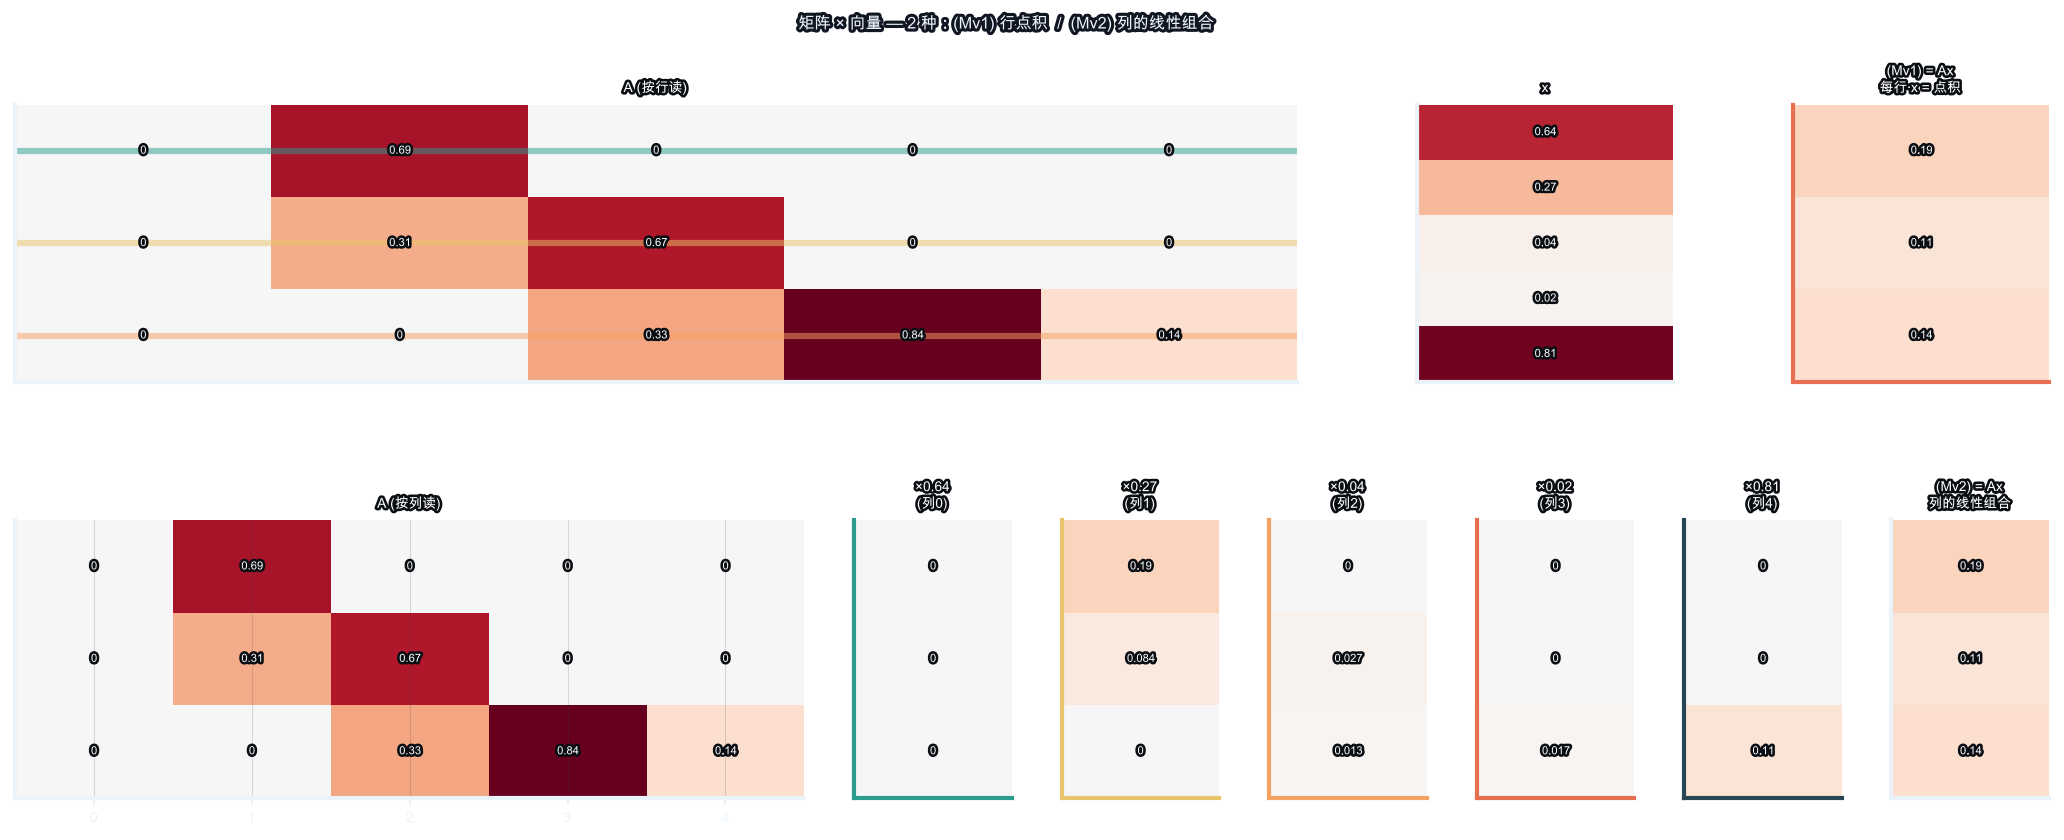

In [17]:
rng = np.random.default_rng(0)
Msmall = np.round(M[:3, :5], 2)         # 取 3 个滤波器 × 5 个频点
p = np.round(rng.random(5), 2)          # 假装的功率谱
mat_times_vec(Msmall, p);               # 每个 mel = 一行·p = 点积

**🎉 收束**：
- **FFT** = 矩阵 `W` × 信号（`v1` 的 Mv 图）
- **mel 特征** = 矩阵 `M` × 功率谱
- **神经网络层** = 矩阵 `W` × 输入

同一张「矩阵×向量」的图，贯穿 Audio Core 到深度学习。这就是用**图形化思维**把线代和 Aurora 焊在一起。

In [18]:
import numpy as np

# 简化 DCT 演示（非完整 MFCC）：展示矩阵链乘视角
# 完整 MFCC = 信号 → W(DFT) → 频谱 → M(mel) → log → D(DCT) → MFCC
# 注意：本格跳过了 mel 和 log 步骤，仅演示矩阵链乘结构，且只取前 N//2+1 个独立 bin
N = 16  # 帧长
n = np.arange(N)
W = np.exp(-2j * np.pi * np.outer(n, n) / N)  # DFT
n_half = np.arange(N // 2 + 1)                # 前 N//2+1 = 9 个独立频率 bin
N_half = len(n_half)
DCT_row = lambda ki: np.cos(np.pi * (2*n_half + 1) * ki / (2 * N_half))
D = np.array([DCT_row(ki) for ki in range(4)])  # 前 4 个 DCT 系数，作用在 9 个 bin 上
print(f'W shape = {W.shape}')
print(f'D(4 MFCC) shape = {D.shape}')
x = np.random.default_rng(0).standard_normal(N)
spectrum = np.abs(W @ x)**2  # 功率谱
mfcc4 = D @ spectrum[:N//2+1]  # DCT 前4阶（简化版，跳过Mel；只取独立 bin）
print(f'mfcc(前4阶) = {np.round(mfcc4, 4)}')


W shape = (16, 16)
D(4 MFCC) shape = (4, 9)
mfcc(前4阶) = [120.0983  35.5776  14.104    9.4705]


### 补充：这里的"简化 DCT 演示"到底简化了什么？能不能跟真实 MFCC 比？

完整的 MFCC 提取管道是五步：
`信号 x → DFT(W) → 功率谱 |X|² → Mel 滤波(M) → log → DCT(D) → MFCC`

上面这格代码故意跳过了"Mel 滤波"和"log"两步，直接对功率谱做 DCT。这么做是为了先让你看清一件事——**MFCC 本质上是好几个矩阵按顺序连乘**（W 接 M 接 D，是一条"矩阵链"），至于每一步具体在做什么、log 为什么必要（模拟人耳对响度的对数感知），不是本课重点，后面的音频课会专门展开。

所以：**这格算出来的 `mfcc4` 不能直接跟真实的 `mel_spectrogram`/MFCC 结果比较数值**——它们不同，因为真实管道多了 mel 压缩和 log 压缩两步非线性变换。这格的价值只在于"结构"：让你看到"信号进、矩阵链乘、系数出"这个骨架。下面补一个对照，用 Aurora 真正的 mel 滤波器 + log，看看"跳步版"和"更完整版"数值差多少：

In [19]:
from aurora.audio import mel_filterbank as _mel_fb

M_full = _mel_fb(n_mels=8, n_fft=N, sample_rate=16000)      # N=16，来自上一格
mel_energy_full = M_full @ spectrum[:N // 2 + 1]
log_mel_full = np.log(mel_energy_full + 1e-9)
print('跳步版 mfcc4 (无 mel、无 log)         :', np.round(mfcc4, 4))
print('更完整版 log-mel 能量 (8 个 mel 频带) :', np.round(log_mel_full, 4))
print('两者数值范围、物理含义都不同——跳步版只演示矩阵链乘的"骨架"，不是真正的 MFCC。')

跳步版 mfcc4 (无 mel、无 log)         : [120.0983  35.5776  14.104    9.4705]
更完整版 log-mel 能量 (8 个 mel 频带) : [-20.7233 -20.7233   3.4889   1.8503   1.175    2.8381   2.6357   2.8549]
两者数值范围、物理含义都不同——跳步版只演示矩阵链乘的"骨架"，不是真正的 MFCC。


## 参数实验：只改一个旋钮

把 `mel_filterbank` 的 `n_mels` 从 `80` 改到 `40`：mel 矩阵 `M` 的 shape 从 `(80, F)` 变为 `(40, F)`，最终特征向量维度减半。减少滤波器数量会使相邻频率 bin 被合并进同一个三角窗，高频细节分辨率下降。反向将 `n_mels` 增到 `128`，观察矩阵行数增加后滤波器重叠程度如何变化，以及 `M @ p` 输出向量的长度是否随之同步增长。

In [20]:
# 参数实验：改变 n_mels，观察 mel 矩阵的 shape 变化
for nm in [40, 80, 128]:
    M_exp = mel_filterbank(nm, 64, 16000)
    print(f'n_mels={nm:3d}  →  mel 矩阵 shape = {M_exp.shape}  ')
# 增大 n_mels → 更多三角窗 → 输出特征维度升高（高频分辨率提升，矩阵行数增加）


n_mels= 40  →  mel 矩阵 shape = (40, 33)  
n_mels= 80  →  mel 矩阵 shape = (80, 33)  
n_mels=128  →  mel 矩阵 shape = (128, 33)  


### 补充：怎么"看到"滤波器之间的重叠程度？

"重叠"指的是：相邻两个三角滤波器，在同一个频率 bin 上是否都不为零。量化的办法很直接——对每一对相邻滤波器（第 m 行和第 m+1 行），数一数有多少个 bin 满足"两行都大于 0"，除以其中一个滤波器覆盖的 bin 总数，就得到"重叠比例"。滤波器越多（n_mels 越大），每个三角形越窄，但由于总频率范围不变，相邻滤波器的重叠比例通常保持在相近水平——这是 mel 滤波器组的设计特点：每个滤波器和左右邻居各重叠约一半，保证功率谱上任何一点的能量都不会被"漏算"。

In [21]:
def overlap_ratio(M_in):
    ratios = []
    for m in range(M_in.shape[0] - 1):
        a, b = M_in[m] > 0, M_in[m + 1] > 0
        cover = np.sum(a)
        ratios.append(np.sum(a & b) / cover if cover > 0 else 0.0)
    return np.array(ratios)

for nm in [40, 80, 128]:
    M_exp = mel_filterbank(nm, 64, 16000)
    r = overlap_ratio(M_exp)
    print(f'n_mels={nm:3d}  平均相邻重叠比例 = {r.mean():.2f}')

n_mels= 40  平均相邻重叠比例 = 0.43
n_mels= 80  平均相邻重叠比例 = 0.32
n_mels=128  平均相邻重叠比例 = 0.24


## 本课收束

现在可以显式构造 DFT 矩阵 `W = exp(-2πi·kn/N)`，运行 `W @ x` 并与 `fft(x)` 数值对比，两者完全一致。mel 矩阵 `M` 的每一行是一个三角滤波器，`M @ p` 等于 `mel_filterbank()` 对功率谱向量 `p` 的输出。这两个变换在 Audio Core 里分别封装为 `fft()` 和 `mel_filterbank()`，底层都是加权点积。下一课：**L22** 导数基础——从 Δy/Δx 出发，为梯度下降和反向传播建立数学基础。

In [22]:
# ── TODO 练习 1：自己构造 DFT 矩阵 ──────────────────────────────────────────
# 不调用任何现有 fft 或 np.fft.*，只用 np.exp / np.arange 构造 N×N 矩阵
# 验收标准：下面注释掉的验证格里的 assert 就是唯一标准——通过即算完成，没有另外的"标准答案"文件。
def build_dft_matrix(N: int) -> np.ndarray:
    """返回 N×N DFT 矩阵 W，满足 W @ x == np.fft.fft(x)。"""
    # TODO: 填写你的实现（提示：W[k,n] = exp(-2πi·k·n/N)，用 np.outer 一行构造）
    raise NotImplementedError('请实现 build_dft_matrix')

# 取消注释来运行验证
# x_test = np.random.default_rng(42).standard_normal(8)
# try:
#     W_test = build_dft_matrix(8)
#     assert np.allclose(W_test @ x_test, np.fft.fft(x_test), atol=1e-10), \
#         f'数值不一致！最大误差: {np.max(np.abs(W_test @ x_test - np.fft.fft(x_test))):.2e}'
#     print('✅ build_dft_matrix 验证通过')
# except (NotImplementedError, TypeError):
#     print('⏳ 尚未实现')


# ── TODO 练习 2：手动构造 3-filter mel 矩阵 ─────────────────────────────────
# N_fft=16，N_mels=3，bins=0..8，用 linspace 端点法构造三角滤波器矩阵
#
# 关于函数名里的"simple"：这里的滤波器中心是在**线性频率刻度**上等距排列的
# （直接对 bin 编号用 np.linspace），不像 Aurora 真正的 mel_filterbank() 那样先把
# 频率转换到 mel 刻度（hz_to_mel）再等距排列、最后转回 Hz。也就是说，
# "simple" = 跳过了 mel 刻度换算，只练习"用 N_mels+2 个端点构造三角滤波器矩阵"
# 这个操作本身——形状、构造逻辑跟 cell-8（前面的简化 mel 演示）一致，只是把
# N_fft 从 8 换成了 16。
# 验收标准同样是下面注释掉的 assert：通过即完成，不需要跟 mel_filterbank() 数值对比
# （因为刻度不同，本来就不会完全一致）。若遇到"全零行"，参考前面 cell-8 之后的
# "+1e-9 与全零行"补充说明——通常是 n_mels 相对 n_fft 太大导致的退化，而不是代码错误。
def build_simple_mel_matrix(n_mels: int, n_fft: int) -> np.ndarray:
    """返回 (n_mels, n_fft//2+1) 的线性刻度三角形滤波器矩阵。"""
    # TODO: 填写你的实现（参考 cell-8 的修复版逻辑）
    raise NotImplementedError('请实现 build_simple_mel_matrix')

# 取消注释来运行验证
# try:
#     M_test = build_simple_mel_matrix(3, 16)
#     print('M_test shape:', M_test.shape)
#     assert M_test.shape == (3, 9), f'期望 (3, 9)，实际 {M_test.shape}'
#     assert M_test[0].sum() > 0, 'filter 0 不应全零'
#     print('✅ build_simple_mel_matrix 验证通过')
# except (NotImplementedError, TypeError):
#     print('⏳ 尚未实现')


---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：DFT 矩阵手算（目标 8 分钟）

盖上屏幕，纸上作答：

**问 1**：N=8 的 DFT 矩阵，W[2,3] = exp(?) = ?
（提示：W[k,n] = exp(-2πi·kn/N)，计算指数）

**问 2**：DFT 矩阵 W（N=8）满足 W·Wᴴ = ?（结果是多少倍的单位矩阵？）

**问 3**：mel 矩阵 M 的形状是 (80, 1025)。输入功率谱 `p` 的形状是 (1025,)。  
`M @ p` 的输出形状是多少？每个输出值代表什么？

**问 4**：`build_dft_matrix(N)` 的一行实现是什么？  
（提示：用 `np.outer` 一行完成）

推导完成后运行下面格对答案。

In [23]:
# ✏️ 对答案格
import numpy as np

N = 8

# 问1：W[2,3] = exp(-2πi·2·3/8)
k, n = 2, 3
w_23 = np.exp(-2j * np.pi * k * n / N)
# exp(-2πi·6/8) = exp(-3πi/2) = 0 + i·1 = j
assert np.isclose(w_23.real, 0.0, atol=1e-12) and np.isclose(w_23.imag, 1.0, atol=1e-12), \
    f"W[2,3] 应为 j，得到 {w_23}"
print(f"Q1 ✅  W[2,3] = exp(-2πi·6/8) = {w_23:.4f}  （= +j）")

# 问2：W·Wᴴ = N·I
k_idx = np.arange(N)[:, None]
n_idx = np.arange(N)[None, :]
W = np.exp(-2j * np.pi * k_idx * n_idx / N)
prod = W @ W.conj().T
assert np.allclose(prod, N * np.eye(N), atol=1e-10), f"W·Wᴴ 应为 {N}·I"
print(f"Q2 ✅  W·Wᴴ = {N}·I  （DFT 矩阵是酉矩阵的 √N 倍）")

# 问3：mel 矩阵 shape
n_mels, n_fft = 80, 2048
n_freq = n_fft // 2 + 1   # 1025
M_shape = (n_mels, n_freq)
p_shape = (n_freq,)
out_shape = (n_mels,)
assert M_shape[1] == p_shape[0]
print(f"Q3 ✅  M @ p: ({n_mels},{n_freq}) × ({n_freq},) = ({n_mels},)  每个值=该mel频带的能量")

# 问4：build_dft_matrix
q4_ok = False
try:
    W_built = build_dft_matrix(N)
    x_test = np.random.default_rng(42).standard_normal(N)
    assert np.allclose(W_built @ x_test, np.fft.fft(x_test), atol=1e-10), \
        "build_dft_matrix 与 np.fft.fft 不一致"
    q4_ok = True
    print(f"Q4 ✅  build_dft_matrix(8) 正确实现，与 np.fft.fft 一致")
except (NotImplementedError, TypeError):
    print("⬜ Q4：请先实现 build_dft_matrix()，再运行对答案格")

if q4_ok:
    print("\n🎉 DFT矩阵白板挑战通过！FFT=矩阵乘法的思想已内化。")
else:
    print("\n💡 Q1-Q3 已核对；补完练习格的 build_dft_matrix 后重跑本格拿下 Q4。")

Q1 ✅  W[2,3] = exp(-2πi·6/8) = -0.0000+1.0000j  （= +j）
Q2 ✅  W·Wᴴ = 8·I  （DFT 矩阵是酉矩阵的 √N 倍）
Q3 ✅  M @ p: (80,1025) × (1025,) = (80,)  每个值=该mel频带的能量
⬜ Q4：请先实现 build_dft_matrix()，再运行对答案格

💡 Q1-Q3 已核对；补完练习格的 build_dft_matrix 后重跑本格拿下 Q4。


In [ ]:
# ✏️ 本课自评
l21_review = {
    "dft_matrix_formula":         None,  # 记住 W[k,n] = exp(-2πi·kn/N)？True/False
    "build_dft_matrix_done":      None,  # build_dft_matrix 实现并通过断言？True/False
    "mel_matrix_shape_clear":     None,  # 理解 mel 矩阵形状 (n_mels, n_freq)？True/False
    "unitary_property":           None,  # 理解 W·Wᴴ = N·I（酉矩阵性质）？True/False
    "whiteboard_passed":          None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l21_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l21_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L21 全部通关！进入 L22：导数基础')

---

→ **下一课**　[L22 · 导数](../3_calculus/L22_derivatives.ipynb)

> 下节课将学习 **导数**：切线斜率、极限定义、数值微分 vs 解析微分。